# Premier League 2023/24 predictions

## Importing libraries

In [51]:
# from google.colab import drive
# drive.mount('/content/drive')

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set style
sns.set(style='white')
pd.set_option('display.max_columns', None)

# Load the dataset from the excel file
#file_path = 'all-euro-data-2023-2024.xlsx'
#df = pd.read_excel(file_path, sheet_name='E0')

# updating the dataset with the recent games played
df = pd.read_csv('E0.csv')
# df = pd.read_csv('/content/drive/MyDrive/Datasets/E0.csv')

# Display the first few rows of the dataset
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,A,C Pawson,6,17,1,8,11,8,6,5,0,0,1,0,8.00,5.5,1.33,8.75,5.25,1.34,8.00,5.50,1.35,8.58,5.51,1.37,8.00,5.0,1.25,9.50,5.25,1.33,9.50,5.68,1.39,9.02,5.35,1.35,1.67,2.20,1.68,2.29,1.71,2.40,1.65,2.27,1.50,1.86,2.07,1.86,2.07,1.93,2.09,1.85,2.03,9.00,5.25,1.33,8.75,5.25,1.33,8.50,5.25,1.35,9.62,5.81,1.33,7.50,4.6,1.29,10.50,5.25,1.3,10.50,5.81,1.36,9.27,5.45,1.33,1.67,2.20,1.65,2.35,1.73,2.45,1.64,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,15,6,7,2,12,12,8,3,2,2,0,0,1.18,7.0,15.00,1.17,7.50,15.50,1.20,7.25,14.00,1.18,7.86,15.67,1.12,6.5,12.00,1.14,7.50,17.00,1.21,8.50,17.50,1.18,7.64,15.67,1.44,2.75,1.42,2.93,1.45,2.98,1.42,2.85,-2.00,1.88,2.02,1.88,2.01,1.91,2.06,1.87,1.99,1.18,7.00,15.00,1.18,7.00,14.50,1.20,7.00,14.00,1.19,8.00,16.00,1.12,6.5,12.00,1.22,7.00,13.0,1.22,8.40,19.00,1.19,7.43,15.98,1.50,2.63,1.49,2.65,1.52,2.79,1.49,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,14,16,5,3,9,14,10,4,1,4,0,0,2.70,3.4,2.55,2.65,3.40,2.55,2.70,3.45,2.60,2.70,3.47,2.71,2.62,3.2,2.30,2.63,3.30,2.63,2.80,3.62,2.75,2.69,3.44,2.64,1.90,2.00,1.90,1.99,1.95,2.03,1.88,1.94,0.00,1.95,1.95,1.95,1.95,1.98,1.99,1.94,1.92,2.63,3.50,2.60,2.65,3.50,2.50,2.60,3.50,2.60,2.75,3.60,2.63,2.50,3.2,2.45,2.63,3.50,2.6,2.88,3.67,2.70,2.70,3.53,2.59,1.73,2.10,1.76,2.18,1.83,2.23,1.74,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,H,D Coote,27,9,12,3,11,12,6,7,2,2,0,0,1.33,5.5,9.00,1.32,5.50,9.00,1.35,5.25,8.50,1.33,5.65,9.61,1.25,4.6,8.50,1.29,5.25,10.00,1.36,6.00,10.50,1.33,5.52,9.61,1.62,2.30,1.62,2.40,1.65,2.45,1.61,2.34,-1.50,1.95,1.95,1.95,1.95,1.98,2.00,1.93,1.93,1.25,6.50,11.00,1.26,6.00,11.00,1.30,5.50,9.50,1.27,6.36,11.36,1.22,5.5,9.00,1.25,5.75,13.0,1.34,6.59,13.00,1.28,5.99,10.91,1.53,2.50,1.56,2.54,1.62,2.66,1.55,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,D,S Attwell,19,9,9,2,12,6,10,4,0,2,0,0,2.20,3.4,3.30,2.20,3.40,3.25,2.25,3.40,3.25,2.27,3.45,3.35,2.10,3.2,3.00,2.20,3.30,3.25,2.30,3.57,3.45,2.24,3.43,3.30,2.01,1.89,2.00,1.89,2.04,1.92,1.97,1.86,-0.25,1.93,1.97,1.95,1.95,1.97,2.00,1.92,1.93,2.30,3.20,3.20,2.35,3.20,3.10,2.35,3.25,3.15,2.39,3.32,3.30,2.10,3.2,3.00,2.38,3.20,3.2,2.42,3.42,3.56,2.32,3.28,3.27,2.10,1.73,2.23,1.72,2.26,1.81,2.17,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


## Data cleaning

In [110]:
# steps:
# 1. Check for missing values
missing_values = pd.DataFrame({'Missing Values': df.isnull().sum(), 'Percentage (%)': (df.isnull().sum() / len(df)) * 100})
# Display the results of the checks
missing_values.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
BWCA,12,6.741573
BWCD,12,6.741573
BWCH,12,6.741573
BWH,2,1.123596
BWD,2,1.123596
...,...,...
PSD,0,0.000000
PSH,0,0.000000
IWA,0,0.000000
IWD,0,0.000000


In [111]:
# 2. Check for duplicates
duplicate_rows = df.duplicated().sum()
duplicate_rows

0

In [112]:
# Dropping columns with a high number of missing values or irrelevant to our analysis
irrelevant_columns = df.columns[df.isnull().sum() > (0.5 * len(df))]  # Columns with more than 50% missing values
df_cleaned = df.drop(columns=irrelevant_columns)

# Convert 'Date' to datetime
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], format='%d/%m/%Y')

# Fill missing values in other relevant columns with appropriate values (like median or mode)
# For numerical columns, we use median and for categorical, we use mode
for column in df_cleaned.columns:
    if df_cleaned[column].dtype == 'object':
        df_cleaned[column].fillna(df_cleaned[column].mode()[0], inplace=True)
    else:
        df_cleaned[column].fillna(df_cleaned[column].median(), inplace=True)

# Recheck for missing values
remaining_missing_values = df_cleaned.isnull().sum().sum()

# Basic information after cleaning
print(remaining_missing_values, df_cleaned.info(), df_cleaned.shape)

df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Columns: 106 entries, Div to AvgCAHA
dtypes: datetime64[ns](1), float64(82), int64(16), object(7)
memory usage: 147.5+ KB
0 None (178, 106)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2023-08-11,20:00,Burnley,Man City,0,3,A,0,2,A,C Pawson,6,17,1,8,11,8,6,5,0,0,1,0,8.00,5.5,1.33,8.75,5.25,1.34,8.00,5.50,1.35,8.58,5.51,1.37,8.00,5.0,1.25,9.50,5.25,1.33,9.50,5.68,1.39,9.02,5.35,1.35,1.67,2.20,1.68,2.29,1.71,2.40,1.65,2.27,1.50,1.86,2.07,1.86,2.07,1.93,2.09,1.85,2.03,9.00,5.25,1.33,8.75,5.25,1.33,8.50,5.25,1.35,9.62,5.81,1.33,7.50,4.6,1.29,10.50,5.25,1.3,10.50,5.81,1.36,9.27,5.45,1.33,1.67,2.20,1.65,2.35,1.73,2.45,1.64,2.28,1.50,1.95,1.98,1.95,1.97,2.02,2.00,1.92,1.95
1,E0,2023-08-12,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,15,6,7,2,12,12,8,3,2,2,0,0,1.18,7.0,15.00,1.17,7.50,15.50,1.20,7.25,14.00,1.18,7.86,15.67,1.12,6.5,12.00,1.14,7.50,17.00,1.21,8.50,17.50,1.18,7.64,15.67,1.44,2.75,1.42,2.93,1.45,2.98,1.42,2.85,-2.00,1.88,2.02,1.88,2.01,1.91,2.06,1.87,1.99,1.18,7.00,15.00,1.18,7.00,14.50,1.20,7.00,14.00,1.19,8.00,16.00,1.12,6.5,12.00,1.22,7.00,13.0,1.22,8.40,19.00,1.19,7.43,15.98,1.50,2.63,1.49,2.65,1.52,2.79,1.49,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,2023-08-12,15:00,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,14,16,5,3,9,14,10,4,1,4,0,0,2.70,3.4,2.55,2.65,3.40,2.55,2.70,3.45,2.60,2.70,3.47,2.71,2.62,3.2,2.30,2.63,3.30,2.63,2.80,3.62,2.75,2.69,3.44,2.64,1.90,2.00,1.90,1.99,1.95,2.03,1.88,1.94,0.00,1.95,1.95,1.95,1.95,1.98,1.99,1.94,1.92,2.63,3.50,2.60,2.65,3.50,2.50,2.60,3.50,2.60,2.75,3.60,2.63,2.50,3.2,2.45,2.63,3.50,2.6,2.88,3.67,2.70,2.70,3.53,2.59,1.73,2.10,1.76,2.18,1.83,2.23,1.74,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,2023-08-12,15:00,Brighton,Luton,4,1,H,1,0,H,D Coote,27,9,12,3,11,12,6,7,2,2,0,0,1.33,5.5,9.00,1.32,5.50,9.00,1.35,5.25,8.50,1.33,5.65,9.61,1.25,4.6,8.50,1.29,5.25,10.00,1.36,6.00,10.50,1.33,5.52,9.61,1.62,2.30,1.62,2.40,1.65,2.45,1.61,2.34,-1.50,1.95,1.95,1.95,1.95,1.98,2.00,1.93,1.93,1.25,6.50,11.00,1.26,6.00,11.00,1.30,5.50,9.50,1.27,6.36,11.36,1.22,5.5,9.00,1.25,5.75,13.0,1.34,6.59,13.00,1.28,5.99,10.91,1.53,2.50,1.56,2.54,1.62,2.66,1.55,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,2023-08-12,15:00,Everton,Fulham,0,1,A,0,0,D,S Attwell,19,9,9,2,12,6,10,4,0,2,0,0,2.20,3.4,3.30,2.20,3.40,3.25,2.25,3.40,3.25,2.27,3.45,3.35,2.10,3.2,3.00,2.20,3.30,3.25,2.30,3.57,3.45,2.24,3.43,3.30,2.01,1.89,2.00,1.89,2.04,1.92,1.97,1.86,-0.25,1.93,1.97,1.95,1.95,1.97,2.00,1.92,1.93,2.30,3.20,3.20,2.35,3.20,3.10,2.35,3.25,3.15,2.39,3.32,3.30,2.10,3.2,3.00,2.38,3.20,3.2,2.42,3.42,3.56,2.32,3.28,3.27,2.10,1.73,2.23,1.72,2.26,1.81,2.17,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


In [113]:
for i in df.select_dtypes(exclude=np.number):
  print(df[i].value_counts())
  print(50*'*')

Div
E0    178
Name: count, dtype: int64
**************************************************
Date
30/09/2023    8
21/10/2023    8
04/11/2023    7
16/09/2023    7
25/11/2023    7
23/12/2023    6
02/09/2023    6
12/08/2023    6
07/10/2023    6
09/12/2023    6
06/12/2023    6
26/08/2023    6
02/12/2023    5
24/09/2023    5
11/11/2023    5
03/12/2023    5
29/10/2023    5
12/11/2023    5
23/09/2023    5
19/08/2023    5
10/12/2023    4
17/12/2023    4
08/10/2023    4
28/10/2023    4
16/12/2023    4
27/08/2023    3
03/09/2023    3
05/11/2023    2
26/11/2023    2
05/12/2023    2
07/12/2023    2
17/09/2023    2
20/08/2023    2
13/08/2023    2
15/12/2023    1
21/12/2023    1
22/12/2023    1
11/08/2023    1
22/10/2023    1
27/11/2023    1
06/11/2023    1
27/10/2023    1
23/10/2023    1
03/10/2023    1
02/10/2023    1
01/10/2023    1
18/09/2023    1
01/09/2023    1
25/08/2023    1
21/08/2023    1
18/08/2023    1
14/08/2023    1
24/12/2023    1
Name: count, dtype: int64
******************************

## Feature engineering

### steps:
* Encode Team Names: Use label encoding for 'HomeTeam' and 'AwayTeam'. This will convert team names into numeric values, making them usable for the model.

* Recent Form: Calculate the recent form for each team based on the last 5 matches. We'll use the 'FTR' column to determine wins (W), losses (L), and draws (D). This feature will provide insight into the current performance of the teams.

* Average Goals per Game: Compute the average goals scored per game for both home and away teams. This feature helps understand the offensive strength of the teams.

* Team Points: Calculate the total points accumulated by each team so far in the season. Points are awarded based on wins (3 points), draws (1 point), and losses (0 points).

* Head-to-Head Statistics: Analyze the outcomes of matches between the same pairs of teams earlier in the season.

* Other Statistical Features: Depending on the data available, we can include additional features like average possession, number of shots on target, defensive strength, etc.

## Encode team names

In [114]:
df['HomeTeam'].unique()

array(['Burnley', 'Arsenal', 'Bournemouth', 'Brighton', 'Everton',
       'Sheffield United', 'Newcastle', 'Brentford', 'Chelsea',
       'Man United', "Nott'm Forest", 'Fulham', 'Liverpool', 'Wolves',
       'Tottenham', 'Man City', 'Aston Villa', 'West Ham',
       'Crystal Palace', 'Luton'], dtype=object)

In [115]:
df['AwayTeam'].unique()

array(['Man City', "Nott'm Forest", 'West Ham', 'Luton', 'Fulham',
       'Crystal Palace', 'Aston Villa', 'Tottenham', 'Liverpool',
       'Wolves', 'Sheffield United', 'Brentford', 'Bournemouth',
       'Brighton', 'Man United', 'Newcastle', 'Everton', 'Chelsea',
       'Arsenal', 'Burnley'], dtype=object)

In [116]:
# Import the LabelEncoder class from the sklearn library
from sklearn.preprocessing import LabelEncoder

# Encode the team names
label_encoder = LabelEncoder()
df_cleaned['HomeTeamEncoded'] = label_encoder.fit_transform(df_cleaned['HomeTeam'])
df_cleaned['AwayTeamEncoded'] = label_encoder.transform(df_cleaned['AwayTeam'])

## Recent form

In [117]:
# function to calculate recent form
def calculate_form_points(team, df_cleaned, num_matches=5):
    # Filter the matches for the team
    team_matches = df_cleaned[(df_cleaned['HomeTeam'] == team) | (df_cleaned['AwayTeam'] == team)]
    # Sort by date to get the most recent matches
    team_matches = team_matches.sort_values(by='Date', ascending=False)
    # Get the last 'num_matches' matches
    recent_matches = team_matches.head(num_matches)
    # Calculate form points
    form_points = 0
    for _, row in recent_matches.iterrows():
        if row['HomeTeam'] == team and row['FTR'] == 'H':
            form_points += 3
        elif row['AwayTeam'] == team and row['FTR'] == 'A':
            form_points += 3
        elif row['FTR'] == 'D':
            form_points += 1
    return form_points

# Apply the function to get recent form for each team in each match
df_cleaned['HomeTeamRecentForm'] = df_cleaned.apply(lambda x: calculate_form_points(x['HomeTeam'], df_cleaned), axis=1)
df_cleaned['AwayTeamRecentForm'] = df_cleaned.apply(lambda x: calculate_form_points(x['AwayTeam'], df_cleaned), axis=1)

# Average Goals per Game
df_cleaned['HomeTeamAvgGoals'] = df_cleaned.groupby('HomeTeam')['FTHG'].transform('mean')
df_cleaned['AwayTeamAvgGoals'] = df_cleaned.groupby('AwayTeam')['FTAG'].transform('mean')

## Team Points

In [118]:
# Points will be calculated similar to form but for the whole season
def calculate_team_points(team, df_cleaned):
    team_matches = df_cleaned[(df_cleaned['HomeTeam'] == team) | (df_cleaned['AwayTeam'] == team)]
    points = 0
    for _, row in team_matches.iterrows():
        if row['HomeTeam'] == team and row['FTR'] == 'H':
            points += 3
        elif row['AwayTeam'] == team and row['FTR'] == 'A':
            points += 3
        elif row['FTR'] == 'D':
            points += 1
    return points

df_cleaned['HomeTeamPoints'] = df_cleaned.apply(lambda x: calculate_team_points(x['HomeTeam'], df_cleaned), axis=1)
df_cleaned['AwayTeamPoints'] = df_cleaned.apply(lambda x: calculate_team_points(x['AwayTeam'], df_cleaned), axis=1)

## Head-to-Head Statistics

In [119]:
# Head-to-Head Statistics
# For simplicity, we can count the number of wins, draws, and losses in matches between the same teams
# Note: This implementation is simplified for demonstration purposes
def head_to_head_stats(home_team, away_team, df_cleaned):
    head_to_head_matches = df_cleaned[(df_cleaned['HomeTeam'] == home_team) & (df['AwayTeam'] == away_team)]
    wins = len(head_to_head_matches[head_to_head_matches['FTR'] == 'H'])
    draws = len(head_to_head_matches[head_to_head_matches['FTR'] == 'D'])
    losses = len(head_to_head_matches[head_to_head_matches['FTR'] == 'A'])
    return wins, draws, losses

# Apply the head-to-head stats function
df_cleaned['HeadToHeadWins'], df_cleaned['HeadToHeadDraws'], df_cleaned['HeadToHeadLosses'] = zip(*df_cleaned.apply(lambda x: head_to_head_stats(x['HomeTeam'], x['AwayTeam'], df_cleaned), axis=1))

In [120]:
# Calculate Home Team Win Percentage
home_team_wins = df_cleaned[df_cleaned['FTR'] == 'H'].groupby('HomeTeam').size()
total_home_matches = df_cleaned.groupby('HomeTeam').size()
home_team_win_percentage = home_team_wins / total_home_matches
#
# Calculate Away Team Win Percentage
away_team_wins = df_cleaned[df_cleaned['FTR'] == 'A'].groupby('AwayTeam').size()
total_away_matches = df_cleaned.groupby('AwayTeam').size()
away_team_win_percentage = away_team_wins / total_away_matches
#
# Create mappings for win percentages
home_team_win_percentage_map = home_team_win_percentage.to_dict()
away_team_win_percentage_map = away_team_win_percentage.to_dict()
#
# Map the win percentages to the original DataFrame
df_cleaned['HomeTeamWinPercentage'] = df_cleaned['HomeTeam'].map(home_team_win_percentage_map).fillna(0)
df_cleaned['AwayTeamWinPercentage'] = df_cleaned['AwayTeam'].map(away_team_win_percentage_map).fillna(0)
#
# Check the first few rows to confirm the new features
display(df_cleaned[['HomeTeam', 'HomeTeamWinPercentage', 'AwayTeam', 'AwayTeamWinPercentage']].head())

,HomeTeam,HomeTeamWinPercentage,AwayTeam,AwayTeamWinPercentage
0,Burnley,0.111111,Man City,0.555556
1,Arsenal,0.777778,Nott'm Forest,0.111111
2,Bournemouth,0.250000,West Ham,0.444444
3,Brighton,0.444444,Luton,0.125000
4,Everton,0.333333,Fulham,0.111111


In [121]:
# get the current position and calculate points for chelsea and the rest of the teams
def calculate_points_goals(row):
    home_points, away_points = 0, 0
    home_goal_diff = row['FTHG'] - row['FTAG']
    away_goal_diff = row['FTAG'] - row['FTHG']

    if row['FTR'] == 'H':
        home_points = 3
    elif row['FTR'] == 'A':
        away_points = 3
    else:
        home_points = away_points = 1

    return pd.Series([home_points, away_points, home_goal_diff, away_goal_diff, row['FTHG'], row['FTAG']])

# List of teams
teams = df_cleaned['HomeTeam'].unique()

# Applying the function to the dataset
df_cleaned[['HomePoints', 'AwayPoints', 'HomeGoalDiff', 'AwayGoalDiff', 'HomeGoals', 'AwayGoals']] = df_cleaned.apply(calculate_points_goals, axis=1)

# Summarizing the data for each team
team_stats = pd.DataFrame(index=teams)

# Calculating total points, goal difference, and goals scored for each team
team_stats['Points'] = df_cleaned.groupby('HomeTeam')['HomePoints'].sum() + df_cleaned.groupby('AwayTeam')['AwayPoints'].sum()
team_stats['GoalDiff'] = df_cleaned.groupby('HomeTeam')['HomeGoalDiff'].sum() + df_cleaned.groupby('AwayTeam')['AwayGoalDiff'].sum()
team_stats['GoalsScored'] = df_cleaned.groupby('HomeTeam')['HomeGoals'].sum() + df_cleaned.groupby('AwayTeam')['AwayGoals'].sum()

# Sorting the teams based on Points, Goal Difference, and Goals Scored
sorted_teams = team_stats.sort_values(by=['Points', 'GoalDiff', 'GoalsScored'], ascending=[False, False, False])

# Finding Chelsea's position
chelsea_position_updated = sorted_teams.index.get_loc('Chelsea') + 1
print('Chelsea is currently in position:', chelsea_position_updated)
display(sorted_teams.head(), chelsea_position_updated)

Chelsea is currently in position: 11


,Points,GoalDiff,GoalsScored
Arsenal,40,20,36
Liverpool,39,21,37
Aston Villa,39,16,38
Tottenham,36,13,37
Man City,34,20,40


11

In [122]:
# # Goal Difference
# df_cleaned['GoalDifference'] = df_cleaned['FTHG'] - df_cleaned['FTAG']

# # Team-specific Features
# # df_cleaned['HomeTeamGoalsConceded'] = df_cleaned.groupby('HomeTeam')['FTAG'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
# # df_cleaned['AwayTeamGoalsConceded'] = df_cleaned.groupby('AwayTeam')['FTHG'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
# # df_cleaned['HomeTeamShotsOnTarget'] = df_cleaned.groupby('HomeTeam')['HST'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
# # df_cleaned['AwayTeamShotsOnTarget'] = df_cleaned.groupby('AwayTeam')['AST'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())

# # # Performance in Recent Matches
# # df_cleaned['HomeTeamRecentWins'] = df_cleaned.groupby('HomeTeam')['FTR'].apply(lambda x: x.eq('H').rolling(5).sum().shift())
# # df_cleaned['AwayTeamRecentWins'] = df_cleaned.groupby('AwayTeam')['FTR'].apply(lambda x: x.eq('A').rolling(5).sum().shift())
# # df_cleaned['HomeTeamRecentDraws'] = df_cleaned.groupby('HomeTeam')['FTR'].apply(lambda x: x.eq('D').rolling(5).sum().shift())
# # df_cleaned['AwayTeamRecentDraws'] = df_cleaned.groupby('AwayTeam')['FTR'].apply(lambda x: x.eq('D').rolling(5).sum().shift())

# # Previous Match Result
# # df_cleaned['PreviousMatchResult'] = df_cleaned.groupby(['HomeTeam', 'AwayTeam'])['FTR'].shift()

# # Goal-related Features
# # df_cleaned['HomeTeamGoalDifference'] = df_cleaned.groupby('HomeTeam')['GoalDifference'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
# # df_cleaned['AwayTeamGoalDifference'] = df_cleaned.groupby('AwayTeam')['GoalDifference'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())

# # Betting Odds Features
# df_cleaned['AverageHomeOdds'] = df_cleaned[['B365H', 'BWH', 'IWH', 'PSH', 'WHH', 'VCH']].mean(axis=1)
# df_cleaned['AverageAwayOdds'] = df_cleaned[['B365A', 'BWA', 'IWA', 'PSA', 'WHA', 'VCA']].mean(axis=1)
# df_cleaned['AverageDrawOdds'] = df_cleaned[['B365D', 'BWD', 'IWD', 'PSD', 'WHD', 'VCD']].mean(axis=1)

# df_cleaned.head()

## Data Preprocessing
### steps:
* Scaling Numeric Features: We'll scale features like recent form, average goals, and points using StandardScaler.
* Handling Categorical Variables: We have already encoded team names. We'll ensure other categorical features, if any, are properly encoded.
* Splitting the Data: We'll split the data into training and test sets. We'll use the training set to train the model and the test set to evaluate the model's performance on unseen data.

In [123]:
df_cleaned.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,HomeTeamEncoded,AwayTeamEncoded,HomeTeamRecentForm,AwayTeamRecentForm,HomeTeamAvgGoals,AwayTeamAvgGoals,HomeTeamPoints,AwayTeamPoints,HeadToHeadWins,HeadToHeadDraws,HeadToHeadLosses,HomeTeamWinPercentage,AwayTeamWinPercentage,HomePoints,AwayPoints,HomeGoalDiff,AwayGoalDiff,HomeGoals,AwayGoals
0,E0,2023-08-11,20:00,Burnley,Man City,0,3,A,0,2,A,C Pawson,6,17,1,8,11,8,6,5,0,0,1,0,8.00,5.5,1.33,8.75,5.25,1.34,8.00,5.50,1.35,8.58,5.51,1.37,8.00,5.0,1.25,9.50,5.25,1.33,9.50,5.68,1.39,9.02,5.35,1.35,1.67,2.20,1.68,2.29,1.71,2.40,1.65,2.27,1.50,1.86,2.07,1.86,2.07,1.93,2.09,1.85,2.03,9.00,5.25,1.33,8.75,5.25,1.33,8.50,5.25,1.35,9.62,5.81,1.33,7.50,4.6,1.29,10.50,5.25,1.3,10.50,5.81,1.36,9.27,5.45,1.33,1.67,2.20,1.65,2.35,1.73,2.45,1.64,2.28,1.50,1.95,1.98,1.95,1.97,2.02,2.00,1.92,1.95,5,12,7,6,1.111111,2.000000,11,34,0,0,1,0.111111,0.555556,0,3,-3,3,0,3
1,E0,2023-08-12,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,15,6,7,2,12,12,8,3,2,2,0,0,1.18,7.0,15.00,1.17,7.50,15.50,1.20,7.25,14.00,1.18,7.86,15.67,1.12,6.5,12.00,1.14,7.50,17.00,1.21,8.50,17.50,1.18,7.64,15.67,1.44,2.75,1.42,2.93,1.45,2.98,1.42,2.85,-2.00,1.88,2.02,1.88,2.01,1.91,2.06,1.87,1.99,1.18,7.00,15.00,1.18,7.00,14.50,1.20,7.00,14.00,1.19,8.00,16.00,1.12,6.5,12.00,1.22,7.00,13.0,1.22,8.40,19.00,1.19,7.43,15.98,1.50,2.63,1.49,2.65,1.52,2.79,1.49,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92,0,15,10,1,2.444444,0.777778,40,14,1,0,0,0.777778,0.111111,3,0,1,-1,2,1
2,E0,2023-08-12,15:00,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,14,16,5,3,9,14,10,4,1,4,0,0,2.70,3.4,2.55,2.65,3.40,2.55,2.70,3.45,2.60,2.70,3.47,2.71,2.62,3.2,2.30,2.63,3.30,2.63,2.80,3.62,2.75,2.69,3.44,2.64,1.90,2.00,1.90,1.99,1.95,2.03,1.88,1.94,0.00,1.95,1.95,1.95,1.95,1.98,1.99,1.94,1.92,2.63,3.50,2.60,2.65,3.50,2.50,2.60,3.50,2.60,2.75,3.60,2.63,2.50,3.2,2.45,2.63,3.50,2.6,2.88,3.67,2.70,2.70,3.53,2.59,1.73,2.10,1.76,2.18,1.83,2.23,1.74,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91,2,18,13,10,1.000000,1.555556,22,30,0,1,0,0.250000,0.444444,1,1,0,0,1,1
3,E0,2023-08-12,15:00,Brighton,Luton,4,1,H,1,0,H,D Coote,27,9,12,3,11,12,6,7,2,2,0,0,1.33,5.5,9.00,1.32,5.50,9.00,1.35,5.25,8.50,1.33,5.65,9.61,1.25,4.6,8.50,1.29,5.25,10.00,1.36,6.00,10.50,1.33,5.52,9.61,1.62,2.30,1.62,2.40,1.65,2.45,1.61,2.34,-1.50,1.95,1.95,1.95,1.95,1.98,2.00,1.93,1.93,1.25,6.50,11.00,1.26,6.00,11.00,1.30,5.50,9.50,1.27,6.36,11.36,1.22,5.5,9.00,1.25,5.75,13.0,1.34,6.59,13.00,1.28,5.99,10.91,1.53,2.50,1.56,2.54,1.62,2.66,1.55,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86,4,11,5,6,2.000000,0.875000,27,12,1,0,0,0.444444,0.125000,3,0,3,-3,4,1
4,E0,2023-08-12,15:00,Everton,Fulham,0,1,A,0,0,D,S Attwell,19,9,9,2,12,6,10,4,0,2,0,0,2.20,3.4,3.30,2.20,3.40,3.25,2.25,3.40,3.25,2.27,3.45,3.35,2.10,3.2,3.00,2.20,3.30,3.25,2.30,3.57,3.45,2.24,3.43,3.30,2.01,1.89,2.00,1.89,2.04,1.92,1.97,1.86,-0.25,1.93,1.97,1.95,1.95,1.97,2.00,1.92,1.93,2.30,3.20,3.20,2.35,3.20,3.10,2.35,3.25,3.15,2.39,3.32,3.30,2.10,3.2,3.00,2.38,3.20,3.2,2.42,3.42,3.56,2.32,3.28,3.27,2.10,1.73,2.23,1.72,2.26,1.81,2.17,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88,8,9,12,6,1.111111,1.000000,26,21,0,0,1,0.333333,0.111111,0,3,-1,1,0,1


In [124]:
print('Numerical Features\n: ', list(df_cleaned.select_dtypes(include=np.number).columns))
print('\n\nCategorical Features\n: ', df_cleaned.select_dtypes(exclude=np.number).columns)

Numerical Features
:  ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'HomeTeamEncoded', 'AwayTeamEncoded', 'HomeTeamRecentForm', 'AwayTeamRecentForm', 'HomeTeamAvgGoals', 'AwayTeamAvgGoals', 'HomeT

In [125]:
print(df_cleaned.columns.tolist())

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'HomeTeamEncoded', 'AwayTeamEncoded', 'HomeTeamRecentForm', 'AwayTeamRecentFor

In [126]:
features = features = ['HomeTeamEncoded', 'AwayTeamEncoded', 'HomeTeamRecentForm', 'AwayTeamRecentForm', 'HomeTeamAvgGoals', 
                       'AwayTeamAvgGoals', 'HomeTeamPoints', 'AwayTeamPoints', 'HomeTeamWinPercentage', 'AwayTeamWinPercentage']

target_features = df_cleaned['FTR']

**Encoding ordinal features & Scaling Numerical features**

In [127]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(df):
    # Scaling for continuous features
    scaler = StandardScaler()
    df.loc[:, features] = scaler.fit_transform(df[features])
    return df

In [128]:
df_processed = preprocess_data(df_cleaned[features])

In [129]:
df_processed.head()

,HomeTeamEncoded,AwayTeamEncoded,HomeTeamRecentForm,AwayTeamRecentForm,HomeTeamAvgGoals,AwayTeamAvgGoals,HomeTeamPoints,AwayTeamPoints,HomeTeamWinPercentage,AwayTeamWinPercentage
0,-0.785014,0.427894,-0.006882,-0.328694,-0.970440,1.521540,-1.480929,0.964144,-1.463909,1.299784
1,-1.651842,0.947202,0.911860,-1.852327,1.197824,-1.283709,1.616541,-1.179736,1.283815,-1.278061
2,-1.305111,1.466510,1.830601,0.890213,-1.151129,0.501449,-0.306027,0.535368,-0.891467,0.655323
3,-0.958380,0.254791,-0.619376,-0.328694,0.475069,-1.060565,0.228020,-1.394124,-0.090047,-1.197503
4,-0.264918,-0.091414,1.524354,-0.328694,-0.970440,-0.773664,0.121211,-0.429378,-0.548001,-1.278061


In [130]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HomeTeamEncoded        178 non-null    float64
 1   AwayTeamEncoded        178 non-null    float64
 2   HomeTeamRecentForm     178 non-null    float64
 3   AwayTeamRecentForm     178 non-null    float64
 4   HomeTeamAvgGoals       178 non-null    float64
 5   AwayTeamAvgGoals       178 non-null    float64
 6   HomeTeamPoints         178 non-null    float64
 7   AwayTeamPoints         178 non-null    float64
 8   HomeTeamWinPercentage  178 non-null    float64
 9   AwayTeamWinPercentage  178 non-null    float64
dtypes: float64(10)
memory usage: 14.0 KB


## Model Development

In [131]:
X = df_processed
y = target_features

print(X.shape, y.shape)
print('\n', y.value_counts())

(178, 10) (178,)

 FTR
H    83
A    59
D    36
Name: count, dtype: int64


In [132]:
y = y.map({'A': 2, 'D': 1, 'H': 0})
y.value_counts()

FTR
0    83
2    59
1    36
Name: count, dtype: int64

In [133]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, fbeta_score, recall_score,
                            precision_score, classification_report, roc_auc_score, confusion_matrix, auc)
from hyperopt import fmin, tpe, hp, STATUS_OK
import random

In [148]:
# Define the search space for Hyperopt
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 1000, 50),  # Wide range for exploration
    'max_depth': hp.choice('max_depth', range(3, 15)),      # Flexibility in tree depth
    'learning_rate': hp.loguniform('learning_rate', np.log(0.001), np.log(0.03)), # Fine-tune update speed
    'subsample': hp.uniform('subsample', 0.6, 1),       # Control feature randomness
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),  # Randomness in tree building
    'gamma': hp.uniform('gamma', 0, 5),                  # Adjust tree splits
    'min_child_weight': hp.quniform('min_child_weight', 1, 11, 1),  # Handle imbalanced data
    'reg_lambda': hp.uniform('reg_lambda', 1e-8, 1),     # Prevent overfitting
}

# Objective function with early stopping
def objective(params):
    params.update({key: int(value) if key in ('n_estimators', 'max_depth', 'min_child_weight') else value for key, value in params.items()})
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=101)

    xgb_model = xgb.XGBClassifier(**params, random_state=101, eval_metric=['mlogloss', 'merror'], early_stopping_rounds=100)

    scores = []
    for train_index, test_index in skf.split(X, y):
        xgb_model.fit(X.iloc[train_index], y.iloc[train_index], eval_set=[(X.iloc[test_index], y.iloc[test_index])], verbose=False)
        scores.append(accuracy_score(y.iloc[test_index], xgb_model.predict(X.iloc[test_index])))

    mean_scores = np.mean(scores)
    loss = 1 - mean_scores

    return {'loss': loss, 'status': STATUS_OK, 'params': params}

# Hyperparameter optimization
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100)

# Extract the best parameters
best_params = {key: int(value) if key in ('n_estimators', 'max_depth', 'min_child_weight') else value for key, value
               in best.items() if key not in ('loss', 'status')}
print("\nBest Parameters:", best_params)

100%|██████████████████████████████████████████████| 100/100 [04:27<00:00,  2.67s/trial, best loss: 0.3477124183006536]

Best Parameters: {'colsample_bytree': 0.7310169962392646, 'gamma': 2.8431073543138914, 'learning_rate': 0.0026107458667951923, 'max_depth': 7, 'min_child_weight': 9, 'n_estimators': 450, 'reg_lambda': 0.628298527050537, 'subsample': 0.6999690339809604}


In [137]:
best_param = {'colsample_bytree': 0.8529181891389495, 'gamma': 0.01347104974054214, 'learning_rate': 0.34793992027996196, 
               'max_depth': 10, 'min_child_weight': 8, 'n_estimators': 350, 'reg_lambda': 4.333539836229903, 
               'subsample': 0.8637020461156705
              }

In [149]:
xgb_model = xgb.XGBClassifier(**best_params, random_state=101, eval_metric=['mlogloss', 'merror'], 
                              early_stopping_rounds=100, objective='multi:softprob')

# rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=101)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

recall_train, accuracy_train, precision_train, f1_train, confusion_matrices_train = [], [], [], [], []
recall_val, accuracy_val, precision_val, f1_val, confusion_matrices_val = [], [], [], [], []

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    X_train, X_val = X.values[train_index], X.values[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_pred = xgb_model.predict(X_train)  # Train set
    y_pred = xgb_model.predict(X_val)     # Validation set

    # Combined metric calculations
    train_metrics = (
        recall_score(y_train, train_pred, average='weighted'), 
        accuracy_score(y_train, train_pred),
        precision_score(y_train, train_pred, average='weighted', zero_division=0),
        f1_score(y_train, train_pred, average='weighted'),
        confusion_matrix(y_train, train_pred)
    )

    val_metrics = (
        recall_score(y_val, y_pred, average='weighted'),
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred, average='weighted', zero_division=0),
        f1_score(y_val, y_pred, average='weighted'),
        confusion_matrix(y_val, y_pred)
    )

    # Append metrics to lists
    recall_train.append(train_metrics[0])
    accuracy_train.append(train_metrics[1])
    precision_train.append(train_metrics[2])
    f1_train.append(train_metrics[3])
    confusion_matrices_train.append(train_metrics[4])

    recall_val.append(val_metrics[0])
    accuracy_val.append(val_metrics[1])
    precision_val.append(val_metrics[2])
    f1_val.append(val_metrics[3])
    confusion_matrices_val.append(val_metrics[4])

# Calculate means of metrics for Training set
mean_recall_train = np.mean(recall_train)
mean_accuracy_train = np.mean(accuracy_train)
mean_precision_train = np.mean(precision_train)
mean_f1_train = np.mean(f1_train)

# Calculate means of metrics for Validation set
mean_recall_val = np.mean(recall_val)
mean_accuracy_val = np.mean(accuracy_val)
mean_precision_val = np.mean(precision_val)
mean_f1_val = np.mean(f1_val)

# Display evaluation metrics for Training set
print("\nTraining Set Metrics:")
print("Mean Recall Train:", mean_recall_train)
print("Mean Accuracy Train:", mean_accuracy_train)
print("Mean Precision Train:", mean_precision_train)
print("Mean F1 Train:", mean_f1_train)

# Display evaluation metrics for Validation set
print("\nValidation Set Metrics:")
print("Mean Recall Val:", mean_recall_val)
print("Mean Accuracy Val:", mean_accuracy_val)
print("Mean Precision Val:", mean_precision_val)
print("Mean F1 Val:", mean_f1_val)


Training Set Metrics:
Mean Recall Train: 0.6166256278932336
Mean Accuracy Train: 0.6166256278932336
Mean Precision Train: 0.5156511219752834
Mean F1 Train: 0.5494936646733264

Validation Set Metrics:
Mean Recall Val: 0.6290476190476191
Mean Accuracy Val: 0.6290476190476191
Mean Precision Val: 0.5144309764309765
Mean F1 Val: 0.5597828798389808


In [94]:
# # save xgboost model
# import pickle
# model_filename = 'best_xgb_model.pkl'

# # Save the trained model
# with open(model_filename, 'wb') as model_file:
#     pickle.dump(xgb_model, model_file)

# print(f"XGBoost model saved to {model_filename}")

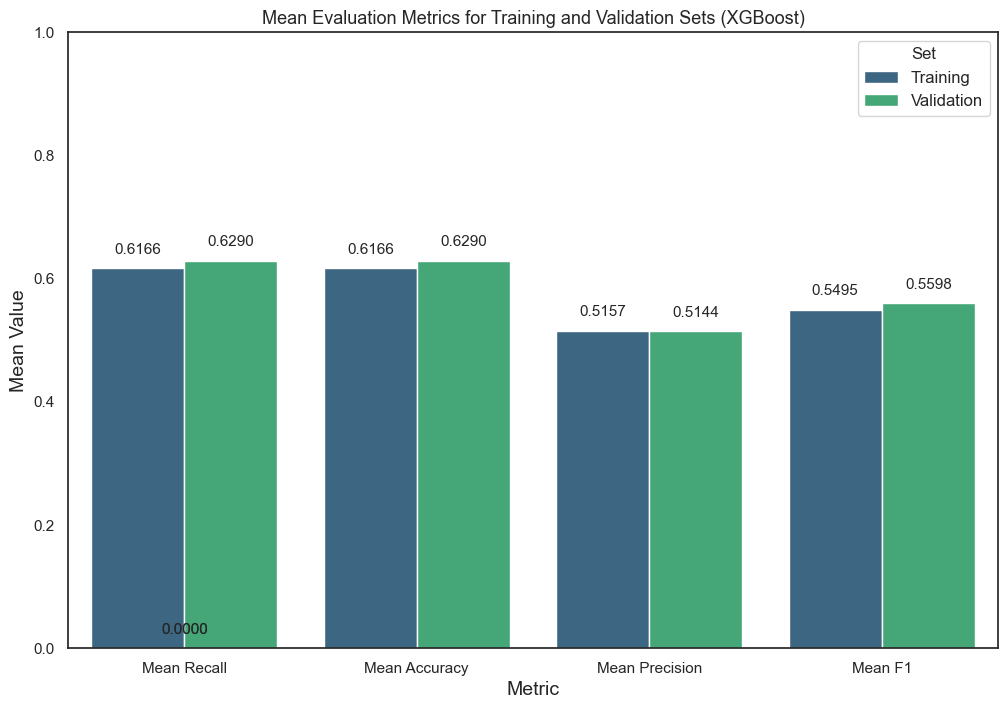

In [150]:
# Combine metrics
metrics_and_sets = [
    ('Mean Recall', mean_recall_train, 'Training'),
    ('Mean Accuracy', mean_accuracy_train, 'Training'),
    ('Mean Precision', mean_precision_train, 'Training'),
    ('Mean F1', mean_f1_train, 'Training'),
    ('Mean Recall', mean_recall_val, 'Validation'),
    ('Mean Accuracy', mean_accuracy_val, 'Validation'),
    ('Mean Precision', mean_precision_val, 'Validation'),
    ('Mean F1', mean_f1_val, 'Validation'),
]

df_plot = pd.DataFrame(metrics_and_sets, columns=['Metric', 'Value', 'Set'])

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Metric', y='Value', hue='Set', data=df_plot, palette='viridis')

# labels and annotations
ax.set_title('Mean Evaluation Metrics for Training and Validation Sets (XGBoost)', fontsize=13)
ax.set_xlabel('Metric', fontsize=14)
ax.set_ylabel('Mean Value', fontsize=14)
ax.legend(title='Set', fontsize=12)
ax.set_ylim(0, 1)

# Add values on top of bars with clear formatting and spacing
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.03),
                ha='center', va='center', fontsize=11)
plt.show();

In [151]:
# print(df_cleaned.loc[df_cleaned['HomeTeam'] == 'Crystal Palace', 'HTR'].values[0])
# print(df_cleaned.loc[df_cleaned['AwayTeam'] == 'Tottenham', 'HTR'].values[0])

In [152]:
def predict_match(home_team, away_team, model):
    # Encode home team
    home_team_encoded = df_cleaned.loc[df_cleaned['HomeTeam'] == home_team, 'HomeTeamEncoded'].values[0]
    # Encode away team
    away_team_encoded = df_cleaned.loc[df_cleaned['HomeTeam'] == away_team, 'HomeTeamEncoded'].values[0]

    # Calculate recent form for home and away teams
    home_recent_form = calculate_form_points(home_team, df_cleaned)
    away_recent_form = calculate_form_points(away_team, df_cleaned)

    new_match_data = pd.DataFrame({
        'HomeTeamEncoded': home_team_encoded,
        'AwayTeamEncoded': away_team_encoded,
        'HomeTeamRecentForm': [home_recent_form],
        'AwayTeamRecentForm': [away_recent_form],
        'HomeTeamAvgGoals': [df_cleaned.loc[df_cleaned['HomeTeam'] == home_team, 'FTHG'].mean()],
        'AwayTeamAvgGoals': [df_cleaned.loc[df_cleaned['AwayTeam'] == away_team, 'FTAG'].mean()],
        'HomeTeamPoints': [calculate_team_points(home_team, df_cleaned)],
        'AwayTeamPoints': [calculate_team_points(away_team, df_cleaned)],
        'HomeTeamWinPercentage': [home_team_win_percentage_map.get(home_team, 0)],
        'AwayTeamWinPercentage': [away_team_win_percentage_map.get(away_team, 0)],
    })

    # # Scale numerical features
    # scaler = StandardScaler()
    # new_match_data = scaler.fit_transform(new_match_data)

    # Make predictions for the specific match (prediction probabilities)
    match_prediction_proba = model.predict_proba(new_match_data)

    # Display only the probabilities of interest
    home_team_win_prob = match_prediction_proba[0, 0]
    away_team_win_prob = match_prediction_proba[0, 2]
    draw_prob = match_prediction_proba[0, 1]

    print("Prediction Probabilities for the match between {} (Home Team) and {} (Away Team):\n".format(home_team, away_team))
    print("Home Team Win Probability:", home_team_win_prob)
    print("Away Team Win Probability:", away_team_win_prob)
    print("Draw Probability:", draw_prob)

In [153]:
# make predictions for the 2023/24 season

matches = [('Burnley', "Man City"),
           ('Arsenal', "Nott'm Forest")]

for home_team, away_team in matches:
    predict_match(home_team, away_team, xgb_model)
    print('\n')

Prediction Probabilities for the match between Burnley (Home Team) and Man City (Away Team):

Home Team Win Probability: 0.3343023
Away Team Win Probability: 0.33258888
Draw Probability: 0.33310884


Prediction Probabilities for the match between Arsenal (Home Team) and Nott'm Forest (Away Team):

Home Team Win Probability: 0.3354592
Away Team Win Probability: 0.3320109
Draw Probability: 0.3325299




In [154]:
# make predictions for the 2023/24 season

matches = [('Newcastle', "Nott'm Forest"),
           ('Bournemouth', 'Fulham'),
           ('Sheffield United', 'Luton'),
           ('Burnley', 'Liverpool'),
           ('Man United', 'Aston Villa')]

for home_team, away_team in matches:
    predict_match(home_team, away_team, xgb_model)
    print('\n')

Prediction Probabilities for the match between Newcastle (Home Team) and Nott'm Forest (Away Team):

Home Team Win Probability: 0.3354592
Away Team Win Probability: 0.3320109
Draw Probability: 0.3325299


Prediction Probabilities for the match between Bournemouth (Home Team) and Fulham (Away Team):

Home Team Win Probability: 0.3343023
Away Team Win Probability: 0.33258888
Draw Probability: 0.33310884


Prediction Probabilities for the match between Sheffield United (Home Team) and Luton (Away Team):

Home Team Win Probability: 0.3343023
Away Team Win Probability: 0.33258888
Draw Probability: 0.33310884


Prediction Probabilities for the match between Burnley (Home Team) and Liverpool (Away Team):

Home Team Win Probability: 0.3343023
Away Team Win Probability: 0.33258888
Draw Probability: 0.33310884


Prediction Probabilities for the match between Man United (Home Team) and Aston Villa (Away Team):

Home Team Win Probability: 0.3354592
Away Team Win Probability: 0.3320109
Draw Probabi

In [428]:
# make predictions for the 2023/24 season

matches = [('Newcastle', "Nott'm Forest"),
           ('Bournemouth', 'Fulham'),
           ('Sheffield United', 'Luton'),
           ('Burnley', 'Liverpool'),
           ('Man United', 'Aston Villa')]

for home_team, away_team in matches:
    predict_match(home_team, away_team, xgb_model)
    print('\n')

Prediction Probabilities for the match between Newcastle (Home Team) and Nott'm Forest (Away Team):

Home Team Win Probability: 0.54176176
Away Team Win Probability: 0.073089376
Draw Probability: 0.38514888


Prediction Probabilities for the match between Bournemouth (Home Team) and Fulham (Away Team):

Home Team Win Probability: 0.2352629
Away Team Win Probability: 0.12801407
Draw Probability: 0.63672304


Prediction Probabilities for the match between Sheffield United (Home Team) and Luton (Away Team):

Home Team Win Probability: 0.2352629
Away Team Win Probability: 0.12801407
Draw Probability: 0.63672304


Prediction Probabilities for the match between Burnley (Home Team) and Liverpool (Away Team):

Home Team Win Probability: 0.15742378
Away Team Win Probability: 0.42001933
Draw Probability: 0.4225569


Prediction Probabilities for the match between Man United (Home Team) and Aston Villa (Away Team):

Home Team Win Probability: 0.2936585
Away Team Win Probability: 0.13278115
Draw Pr

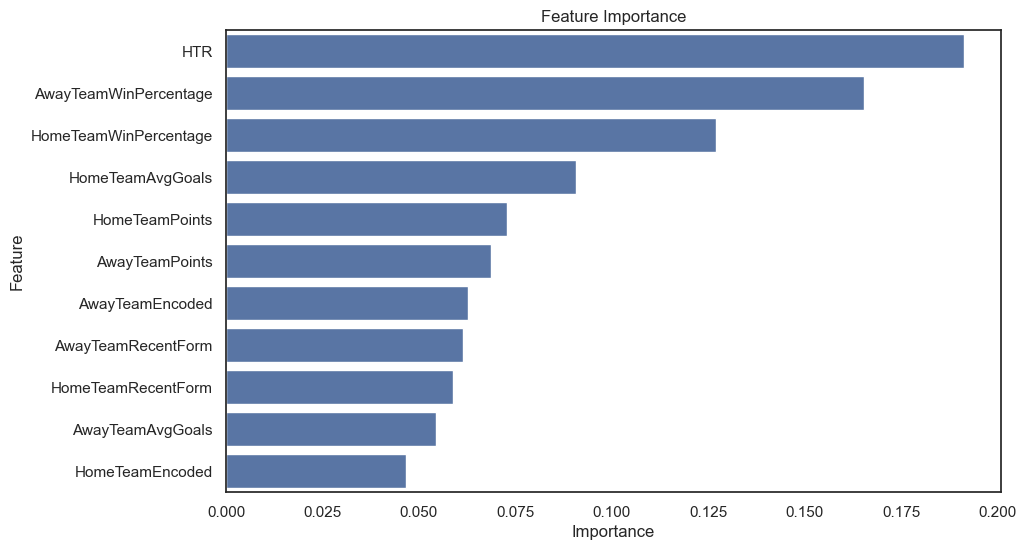

In [429]:
# Get feature importances
feature_importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()